## Merges all the availble information into a **Final Dataset** to be used for modeling ##

In [1]:
import pandas as pd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys

sys.path.insert(0, "../../../Modules")

from preprocessing_utils import *


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 10

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
NUTS0 = 'GR'
NUTS2 = 'Thessaly'
NUTS2_EL = 'θεσσαλιας'

In [4]:
timeline_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_Biweekly_2022_filled.csv', encoding=enc)
wnv_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Cases_2022.csv', encoding=enc)

In [5]:
timeline_file.head()

,lau1,region,x,y,dt_placement,year,month,indices_image_date,indices_lat,indices_lon,ndvi_new,ndmi_new,ndwi_new,ndbi_new,ndvi_mean_new,ndmi_mean_new,ndwi_mean_new,ndbi_mean_new,ndvi_std_new,ndmi_std_new,ndwi_std_new,ndbi_std_new,lst_image_date,lst_lat,lst_lon,lst_day_new,lst_night_new,monthly_lst_lat,monthly_lst_lon,lst_jan_day_mean_new,lst_jan_night_mean_new,lst_feb_day_mean_new,lst_feb_night_mean_new,lst_mar_day_mean_new,lst_mar_night_mean_new,lst_apr_day_mean_new,lst_apr_night_mean_new,indices_image_date.1,indices_lat.1,indices_lon.1,acc_rainfall_jan_new,dt_placement_minus_7,dt_placement_minus_14,dt_placement_minus_7_avail,dt_placement_minus_14_avail,acc_rainfall_1week_new,acc_rainfall_2week_new
0,αγιας,θεσσαλιας,22.63715,39.66477,2022-01-01,2022,1,2022-01-30,39.662866,22.635299,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-01-01,39.662866,22.635299,14317.0,13912.0,39.662866,22.635299,14083.318182,13651.789474,14359.071429,13768.416667,14456.400000,13662.357143,15045.882353,14085.125000,2022-01-01,39.650181,22.650104,0.000000,2021-12-25,2021-12-18,2022-12-16,2022-12-16,0.000000,0.000000
1,αγιας,θεσσαλιας,22.63715,39.66477,2022-01-16,2022,1,2022-01-15,39.662866,22.635299,0.323408,0.207092,-0.223242,-0.207092,0.293262,0.160975,-0.210457,-0.160975,0.059568,0.085228,0.055314,0.085228,2022-01-16,39.662866,22.635299,13930.0,13693.0,39.662866,22.635299,14083.318182,13651.789474,14359.071429,13768.416667,14456.400000,13662.357143,15045.882353,14085.125000,2022-01-16,39.650181,22.650104,218.887877,2022-01-09,2022-01-02,2022-01-09,2022-01-02,217.874235,218.887877
2,αγιας,θεσσαλιας,22.70702,39.75460,2022-01-01,2022,1,2022-01-30,39.752697,22.707165,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-01-01,39.752697,22.707165,NaN,13958.0,39.752697,22.707165,13830.777778,13764.000000,14072.545455,13723.625000,13979.375000,13740.800000,14703.857143,13946.133333,2022-01-01,39.750182,22.750104,0.000000,2021-12-25,2021-12-18,2022-12-16,2022-12-16,0.000000,0.000000
3,αγιας,θεσσαλιας,22.70702,39.75460,2022-01-16,2022,1,2022-01-15,39.752697,22.707165,NaN,NaN,NaN,NaN,0.029346,0.442019,-0.007528,-0.442019,0.000000,0.000000,0.000000,0.000000,2022-01-16,39.752697,22.707165,13697.0,13600.0,39.752697,22.707165,13830.777778,13764.000000,14072.545455,13723.625000,13979.375000,13740.800000,14703.857143,13946.133333,2022-01-16,39.750182,22.750104,239.477200,2022-01-09,2022-01-02,2022-01-09,2022-01-02,238.043966,239.477200
4,αγιας,θεσσαλιας,22.73031,39.79054,2022-01-01,2022,1,2022-01-30,39.788630,22.729622,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-01-01,39.788630,22.729622,NaN,13880.0,39.788630,22.729622,13734.000000,13861.400000,13833.888889,13762.250000,13785.444444,13823.000000,14567.583333,13906.500000,2022-01-01,39.750182,22.750104,0.000000,2021-12-25,2021-12-18,2022-12-16,2022-12-16,0.000000,0.000000


In [6]:
wnv_file.head()

,lau1,nuts2,dt_placement,case
0,κιλελερ,θεσσαλιας,2022-07-01,0
1,κιλελερ,θεσσαλιας,2022-07-16,0
2,κιλελερ,θεσσαλιας,2022-08-01,0
3,κιλελερ,θεσσαλιας,2022-08-16,1
4,κιλελερ,θεσσαλιας,2022-09-01,0


In [7]:
timeline_file.rename(columns={"region": "nuts2"}, inplace=True)

In [8]:
timeline_file = timeline_file.rename(columns=lambda x: re.sub('_new', '', x))

In [9]:
timeline_file.drop(columns=['indices_image_date', 'indices_lat', 'indices_lon' , 'lst_image_date', 'lst_lat','lst_lon' ,'monthly_lst_lat', 'monthly_lst_lon', 
                         'indices_image_date.1', 'indices_lat.1', 'indices_lon.1', 'dt_placement_minus_7', 'dt_placement_minus_14', 'dt_placement_minus_7_avail',
                         'dt_placement_minus_14_avail'], inplace = True)

In [10]:
timeline_file.head(5)

,lau1,nuts2,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,αγιας,θεσσαλιας,22.63715,39.66477,2022-01-01,2022,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14317.0,13912.0,14083.318182,13651.789474,14359.071429,13768.416667,14456.400000,13662.357143,15045.882353,14085.125000,0.000000,0.000000,0.000000
1,αγιας,θεσσαλιας,22.63715,39.66477,2022-01-16,2022,1,0.323408,0.207092,-0.223242,-0.207092,0.293262,0.160975,-0.210457,-0.160975,0.059568,0.085228,0.055314,0.085228,13930.0,13693.0,14083.318182,13651.789474,14359.071429,13768.416667,14456.400000,13662.357143,15045.882353,14085.125000,218.887877,217.874235,218.887877
2,αγιας,θεσσαλιας,22.70702,39.75460,2022-01-01,2022,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13958.0,13830.777778,13764.000000,14072.545455,13723.625000,13979.375000,13740.800000,14703.857143,13946.133333,0.000000,0.000000,0.000000
3,αγιας,θεσσαλιας,22.70702,39.75460,2022-01-16,2022,1,NaN,NaN,NaN,NaN,0.029346,0.442019,-0.007528,-0.442019,0.000000,0.000000,0.000000,0.000000,13697.0,13600.0,13830.777778,13764.000000,14072.545455,13723.625000,13979.375000,13740.800000,14703.857143,13946.133333,239.477200,238.043966,239.477200
4,αγιας,θεσσαλιας,22.73031,39.79054,2022-01-01,2022,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13880.0,13734.000000,13861.400000,13833.888889,13762.250000,13785.444444,13823.000000,14567.583333,13906.500000,0.000000,0.000000,0.000000


In [11]:
wnv_file.head(5)

,lau1,nuts2,dt_placement,case
0,κιλελερ,θεσσαλιας,2022-07-01,0
1,κιλελερ,θεσσαλιας,2022-07-16,0
2,κιλελερ,θεσσαλιας,2022-08-01,0
3,κιλελερ,θεσσαλιας,2022-08-16,1
4,κιλελερ,θεσσαλιας,2022-09-01,0


In [12]:
## Find if there are lau1 units in the epidemiological file and are not contained in the spatiotemporal file.

names_from_wnv_file = wnv_file["lau1"].drop_duplicates().sort_values().tolist()
names_from_shapefile = timeline_file["lau1"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_wnv_file:
    if element not in names_from_shapefile:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")


[]

Length: 0


In [13]:
#wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('ηρωικης πολεως ναουσας','ναουσας'))

In [14]:
## Check again

names_from_wnv_file = wnv_file["lau1"].drop_duplicates().sort_values().tolist()
names_from_shapefile = timeline_file["lau1"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_wnv_file:
    if element not in names_from_shapefile:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")

[]

Length: 0


In [15]:
merged = timeline_file.merge(wnv_file, how='left', on=['dt_placement', 'lau1', 'nuts2'] )

In [16]:
merged

,lau1,nuts2,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case
0,αγιας,θεσσαλιας,22.63715,39.66477,2022-01-01,2022,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14317.0,13912.0,14083.318182,13651.789474,14359.071429,13768.416667,14456.400000,13662.357143,15045.882353,14085.125000,0.000000,0.000000,0.000000,NaN
1,αγιας,θεσσαλιας,22.63715,39.66477,2022-01-16,2022,1,0.323408,0.207092,-0.223242,-0.207092,0.293262,0.160975,-0.210457,-0.160975,0.059568,0.085228,0.055314,0.085228,13930.0,13693.0,14083.318182,13651.789474,14359.071429,13768.416667,14456.400000,13662.357143,15045.882353,14085.125000,218.887877,217.874235,218.887877,NaN
2,αγιας,θεσσαλιας,22.70702,39.75460,2022-01-01,2022,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13958.0,13830.777778,13764.000000,14072.545455,13723.625000,13979.375000,13740.800000,14703.857143,13946.133333,0.000000,0.000000,0.000000,NaN
3,αγιας,θεσσαλιας,22.70702,39.75460,2022-01-16,2022,1,NaN,NaN,NaN,NaN,0.029346,0.442019,-0.007528,-0.442019,0.000000,0.000000,0.000000,0.000000,13697.0,13600.0,13830.777778,13764.000000,14072.545455,13723.625000,13979.375000,13740.800000,14703.857143,13946.133333,239.477200,238.043966,239.477200,NaN
4,αγιας,θεσσαλιας,22.73031,39.79054,2022-01-01,2022,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13880.0,13734.000000,13861.400000,13833.888889,13762.250000,13785.444444,13823.000000,14567.583333,13906.500000,0.000000,0.000000,0.000000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3019,φαρσαλων,θεσσαλιας,22.45598,39.35493,2022-12-16,2022,12,0.048339,-0.123540,-0.073674,0.123540,0.018800,-0.115703,-0.005444,0.115703,0.023313,0.023728,0.060124,0.023728,14469.0,13797.0,14219.210526,13619.333333,14379.176471,13734.909091,14489.363636,13703.900000,14899.625000,14074.600000,1186.034430,12.043608,13.828264,NaN
3020,φαρσαλων,θεσσαλιας,22.45598,39.39086,2022-12-01,2022,12,0.039033,-0.246123,-0.013140,0.246123,0.060820,-0.232368,-0.050633,0.232368,0.023775,0.019335,0.033875,0.019335,14449.0,13783.0,14178.111111,13640.266667,14393.058824,13718.000000,14486.230769,13726.100000,14913.400000,14111.733333,1171.923272,13.280452,54.526232,NaN
3021,φαρσαλων,θεσσαλιας,22.45598,39.39086,2022-12-16,2022,12,0.039033,-0.246123,-0.013140,0.246123,0.060820,-0.232368,-0.050633,0.232368,0.023775,0.019335,0.033875,0.019335,14449.0,14268.0,14178.111111,13640.266667,14393.058824,13718.000000,14486.230769,13726.100000,14913.400000,14111.733333,1186.034430,12.043608,13.828264,NaN
3022,φαρσαλων,θεσσαλιας,22.59495,39.30103,2022-12-01,2022,12,0.075641,0.159641,0.047673,-0.159641,0.073438,0.083757,0.014494,-0.083757,0.028694,0.103486,0.029121,0.103486,14259.0,13781.0,14147.550000,13679.222222,14339.466667,13725.454545,14516.923077,13690.700000,14966.062500,14107.312500,1141.003424,21.631024,60.001182,NaN


In [17]:
merged = fillna(merged,{'case': 0})

In [18]:
merged['case'].value_counts()

0.0    2952
1.0      46
2.0      26
Name: case, dtype: int64

In [19]:
grouped = merged.groupby(['dt_placement', 'lau1', 'nuts2'], as_index = False)

In [20]:
dataset = grouped.mean()

In [21]:
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case
0,2022-01-01,αγιας,θεσσαλιας,22.750267,39.710970,2022.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14281.000000,14035.142857,13946.530227,13768.484943,14128.912163,13770.359127,14179.946149,13771.168878,14711.620173,14042.292792,0.000000,0.000000,0.000000,0.0
1,2022-01-01,αλμυρου,θεσσαλιας,22.692366,39.136391,2022.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14276.375000,14013.555556,14088.341244,13747.596594,14238.749179,13798.552357,14311.203612,13789.415103,14789.425744,14140.293954,0.000138,0.000138,0.000138,0.0
2,2022-01-01,αλοννησου,θεσσαλιας,24.073790,39.328960,2022.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14198.000000,14205.400000,14069.857143,14291.307692,14036.666667,14283.900000,14011.818182,14607.631579,14277.666667,0.453699,0.453699,0.453699,0.0
3,2022-01-01,αργιθεας,θεσσαλιας,21.430513,39.221380,2022.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14173.000000,13969.333333,13813.000000,13614.968219,13999.987179,13683.657576,13976.834832,13600.170655,14591.410256,13998.950794,0.455287,0.455287,0.455287,0.0
4,2022-01-01,βολου,θεσσαλιας,22.883800,39.351977,2022.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14046.333333,14105.000000,14171.453199,13762.569853,14326.441392,13838.500000,14388.153691,13777.372727,14890.170868,14143.785577,0.000000,0.000000,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,2022-12-16,τεμπων,θεσσαλιας,22.553160,39.852112,2022.0,12.0,0.477759,0.152211,-0.389123,-0.152211,0.487939,0.144348,-0.411254,-0.144348,0.051411,0.071228,0.041737,0.071228,14257.000000,14170.400000,13888.346715,13683.892353,14095.155711,13737.560404,14115.457669,13679.157980,14702.253277,14067.814982,1017.411256,8.098654,9.122005,0.0
596,2022-12-16,τρικκαιων,θεσσαλιας,21.797560,39.635058,2022.0,12.0,0.285819,0.004022,-0.221454,-0.004022,0.294226,0.022743,-0.223941,-0.022743,0.044244,0.050393,0.042606,0.050393,14352.200000,14113.200000,14130.884762,13666.107353,14346.223310,13730.069697,14418.705195,13728.572121,14922.437182,14123.490245,1050.398275,29.966226,30.347858,0.0
597,2022-12-16,τυρναβου,θεσσαλιας,22.343000,39.828472,2022.0,12.0,0.453907,0.075541,-0.392130,-0.075541,0.392833,0.053335,-0.334736,-0.053335,0.046209,0.063514,0.034367,0.063514,14344.750000,14051.500000,14077.990981,13625.109743,14283.670940,13724.536859,14387.072650,13681.028283,14882.338796,14095.495475,1029.457235,12.195694,12.909679,0.0
598,2022-12-16,φαρκαδονας,θεσσαλιας,22.020557,39.603750,2022.0,12.0,0.212071,-0.081474,-0.177903,0.081474,0.255763,-0.015408,-0.202076,0.015408,0.060588,0.067927,0.053202,0.067927,14396.666667,14040.333333,14094.681579,13694.162037,14337.983516,13768.886364,14429.993651,13768.516162,14981.523611,14174.105392,1054.837157,46.772979,47.195847,0.0


In [22]:
dataset = dataset.astype({'case': 'int'})

In [23]:
dataset['case'].value_counts()

0    585
1      8
2      7
Name: case, dtype: int64

In [24]:
dataset['dt_placement'] = pd.to_datetime(dataset['dt_placement'])

In [25]:
dataset['x'] = dataset['x'].apply(lambda x : round(x,5))
dataset['y'] = dataset['y'].apply(lambda x : round(x,5))
dataset['day'] = dataset['dt_placement'].apply(lambda x : x.day)
dataset['month'] = dataset['dt_placement'].apply(lambda x : x.month)
dataset['year'] = dataset['dt_placement'].apply(lambda x : x.year)
dataset['week'] = dataset.apply(lambda row: datetime.date(int(row['year']), int(row['month']), int(row['day'])).isocalendar().week, axis=1)

In [26]:
lau1_map = lau1_mapping(dataset, 0, 0)

In [27]:
dataset = encode_cyclical(dataset, 'day', 31)
dataset = encode_cyclical(dataset, 'month', 12)
dataset = encode_cyclical(dataset, 'week', 53)

In [28]:
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case,day,week,eq_distance,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos
0,2022-01-01,αγιας,θεσσαλιας,22.75027,39.71097,2022,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14281.000000,14035.142857,13946.530227,13768.484943,14128.912163,13770.359127,14179.946149,13771.168878,14711.620173,14042.292792,0.000000,0.000000,0.000000,0,1,52,45.76610,0.201299,0.979530,5.000000e-01,0.866025,-0.118273,0.992981
1,2022-01-01,αλμυρου,θεσσαλιας,22.69237,39.13639,2022,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14276.375000,14013.555556,14088.341244,13747.596594,14238.749179,13798.552357,14311.203612,13789.415103,14789.425744,14140.293954,0.000138,0.000138,0.000138,0,1,52,45.23937,0.201299,0.979530,5.000000e-01,0.866025,-0.118273,0.992981
2,2022-01-01,αλοννησου,θεσσαλιας,24.07379,39.32896,2022,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14198.000000,14205.400000,14069.857143,14291.307692,14036.666667,14283.900000,14011.818182,14607.631579,14277.666667,0.453699,0.453699,0.453699,0,1,52,46.11198,0.201299,0.979530,5.000000e-01,0.866025,-0.118273,0.992981
3,2022-01-01,αργιθεας,θεσσαλιας,21.43051,39.22138,2022,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14173.000000,13969.333333,13813.000000,13614.968219,13999.987179,13683.657576,13976.834832,13600.170655,14591.410256,13998.950794,0.455287,0.455287,0.455287,0,1,52,44.69433,0.201299,0.979530,5.000000e-01,0.866025,-0.118273,0.992981
4,2022-01-01,βολου,θεσσαλιας,22.88380,39.35198,2022,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14046.333333,14105.000000,14171.453199,13762.569853,14326.441392,13838.500000,14388.153691,13777.372727,14890.170868,14143.785577,0.000000,0.000000,0.000000,0,1,52,45.52194,0.201299,0.979530,5.000000e-01,0.866025,-0.118273,0.992981
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,2022-12-16,τεμπων,θεσσαλιας,22.55316,39.85211,2022,12,0.477759,0.152211,-0.389123,-0.152211,0.487939,0.144348,-0.411254,-0.144348,0.051411,0.071228,0.041737,0.071228,14257.000000,14170.400000,13888.346715,13683.892353,14095.155711,13737.560404,14115.457669,13679.157980,14702.253277,14067.814982,1017.411256,8.098654,9.122005,0,16,50,45.79122,-0.101168,-0.994869,-2.449294e-16,1.000000,-0.348202,0.937420
596,2022-12-16,τρικκαιων,θεσσαλιας,21.79756,39.63506,2022,12,0.285819,0.004022,-0.221454,-0.004022,0.294226,0.022743,-0.223941,-0.022743,0.044244,0.050393,0.042606,0.050393,14352.200000,14113.200000,14130.884762,13666.107353,14346.223310,13730.069697,14418.705195,13728.572121,14922.437182,14123.490245,1050.398275,29.966226,30.347858,0,16,50,45.23352,-0.101168,-0.994869,-2.449294e-16,1.000000,-0.348202,0.937420
597,2022-12-16,τυρναβου,θεσσαλιας,22.34300,39.82847,2022,12,0.453907,0.075541,-0.392130,-0.075541,0.392833,0.053335,-0.334736,-0.053335,0.046209,0.063514,0.034367,0.063514,14344.750000,14051.500000,14077.990981,13625.109743,14283.670940,13724.536859,14387.072650,13681.028283,14882.338796,14095.495475,1029.457235,12.195694,12.909679,0,16,50,45.66746,-0.101168,-0.994869,-2.449294e-16,1.000000,-0.348202,0.937420
598,2022-12-16,φαρκαδονας,θεσσαλιας,22.02056,39.60375,2022,12,0.212071,-0.081474,-0.177903,0.081474,0.255763,-0.015408,-0.202076,0.015408,0.060588,0.067927,0.053202,0.067927,14396.666667,14040.333333,14094.681579,13694.162037,14337.983516,13768.886364,14429.993651,13768.516162,14981.523611,14174.105392,1054.837157,46.772979,47.195847,0,16,50,45.31404,-0.101168,-0.994869,-2.449294e-16,1.000000,-0.348202,0.937420


<AxesSubplot:>

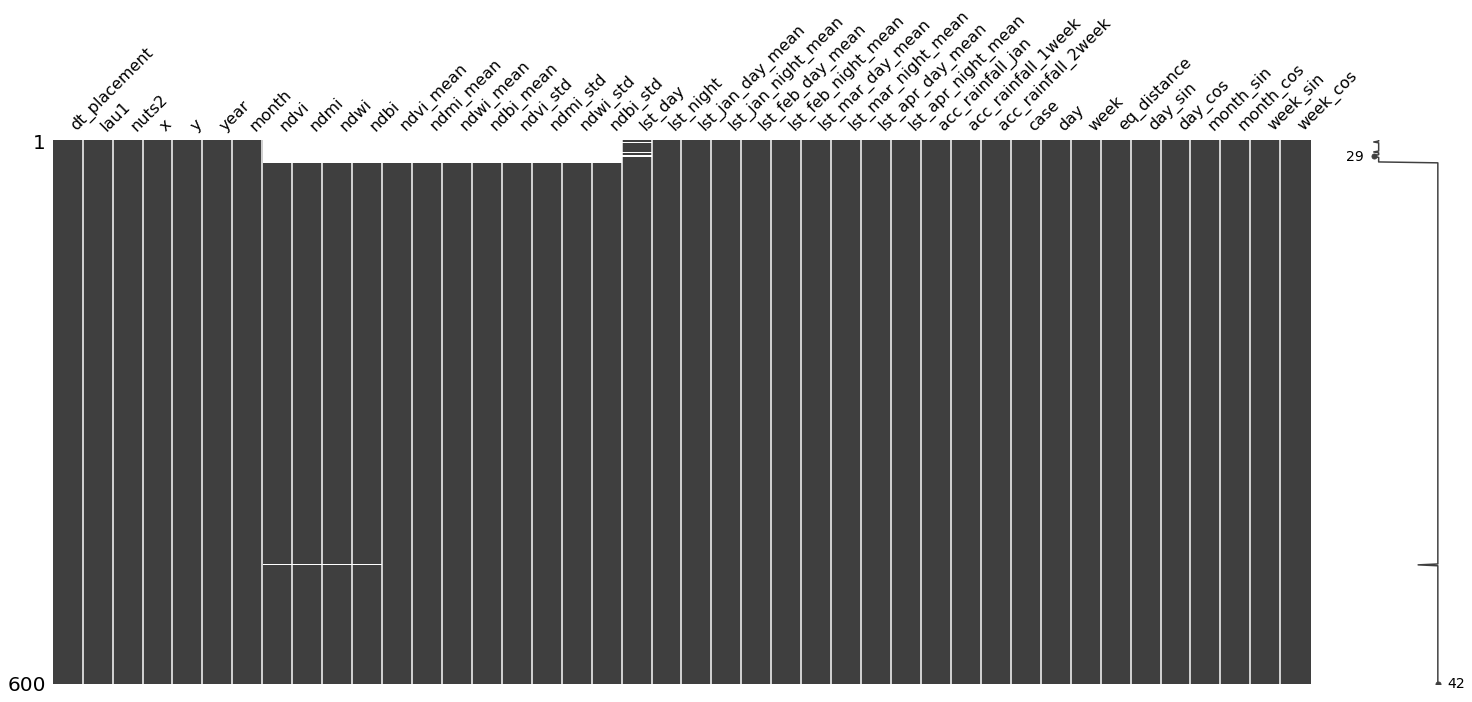

In [29]:
missingno.matrix(dataset)

In [30]:
df_demographics = pd.read_csv(f'../../data/{NUTS0}_WEB_Demographics_Processed.csv', encoding = enc)

In [31]:
df_demographics

,lau1,nuts2,nuts3,area,population_density,population
0,αβδηρων,ανατολικης μακεδονιας και θρακης,ξανθης,352.0,54.0,17860.0
1,αγαθονησιου,νοτιου αιγαιου,καλυμνου,14.5,12.8,203.0
2,αγιας,θεσσαλιας,λαρισας,661.8,17.3,10705.0
3,αγιας βαρβαρας,αττικης,δυτικου τομεα αθηνων,2.4,10925.9,26759.0
4,αγιας παρασκευης,αττικης,βορειου τομεα αθηνων,7.9,7557.5,62157.0
...,...,...,...,...,...,...
327,χανιων,κρητης,χανιων,351.3,309.3,110646.0
328,χερσονησου,κρητης,ηρακλειου,272.2,98.2,27229.0
329,χιου,βορειου αιγαιου,χιου,842.3,61.0,50483.0
330,ωραιοκαστρου,κεντρικης μακεδονιας,θεσσαλονικης,217.9,175.8,40114.0


In [32]:
df_demographics_nuts2 = df_demographics.query(f"nuts2 == '{NUTS2_EL}'").copy()

In [33]:
df_demographics_nuts2.drop(columns=['nuts2', 'nuts3'], inplace=True)
df_demographics_nuts2.reset_index(inplace=True, drop=True)

In [34]:
df_demographics_nuts2

,lau1,area,population_density,population
0,αγιας,661.8,17.3,10705.00
1,αλμυρου,905.4,20.6,16004.00
2,αλοννησου,129.6,21.2,3153.00
3,αργιθεας,372.9,9.3,3515.00
4,βολου,385.6,374.6,138865.00
...,...,...,...,...
20,τεμπων,576.7,23.8,11.99
21,τρικκαιων,607.6,133.9,78508.00
22,τυρναβου,525.3,47.7,22252.00
23,φαρκαδονος,368.7,36.3,11348.00


In [35]:
names_from_merged = dataset["lau1"].drop_duplicates().sort_values().tolist()
names_from_demographics = df_demographics_nuts2["lau1"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_merged:
    if element not in names_from_demographics:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")

['καλαμπακας', 'λαρισαιων', 'ρηγα φερραιου', 'φαρκαδονας']

Length: 4


In [36]:
df_demographics_nuts2['lau1'] = df_demographics_nuts2['lau1'].apply(lambda x : x.replace('μετεωρων','καλαμπακας'))
df_demographics_nuts2['lau1'] = df_demographics_nuts2['lau1'].apply(lambda x : x.replace('λαρισας','λαρισαιων'))
df_demographics_nuts2['lau1'] = df_demographics_nuts2['lau1'].apply(lambda x : x.replace('ρηγα φεραιου','ρηγα φερραιου'))
df_demographics_nuts2['lau1'] = df_demographics_nuts2['lau1'].apply(lambda x : x.replace('φαρκαδονος','φαρκαδονας'))



In [37]:
names_from_merged = dataset["lau1"].drop_duplicates().sort_values().tolist()
names_from_demographics = df_demographics_nuts2["lau1"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_merged:
    if element not in names_from_demographics:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")

[]

Length: 0


In [38]:
dataset = pd.merge(dataset, df_demographics_nuts2,  how='left', on=['lau1'])

<AxesSubplot:>

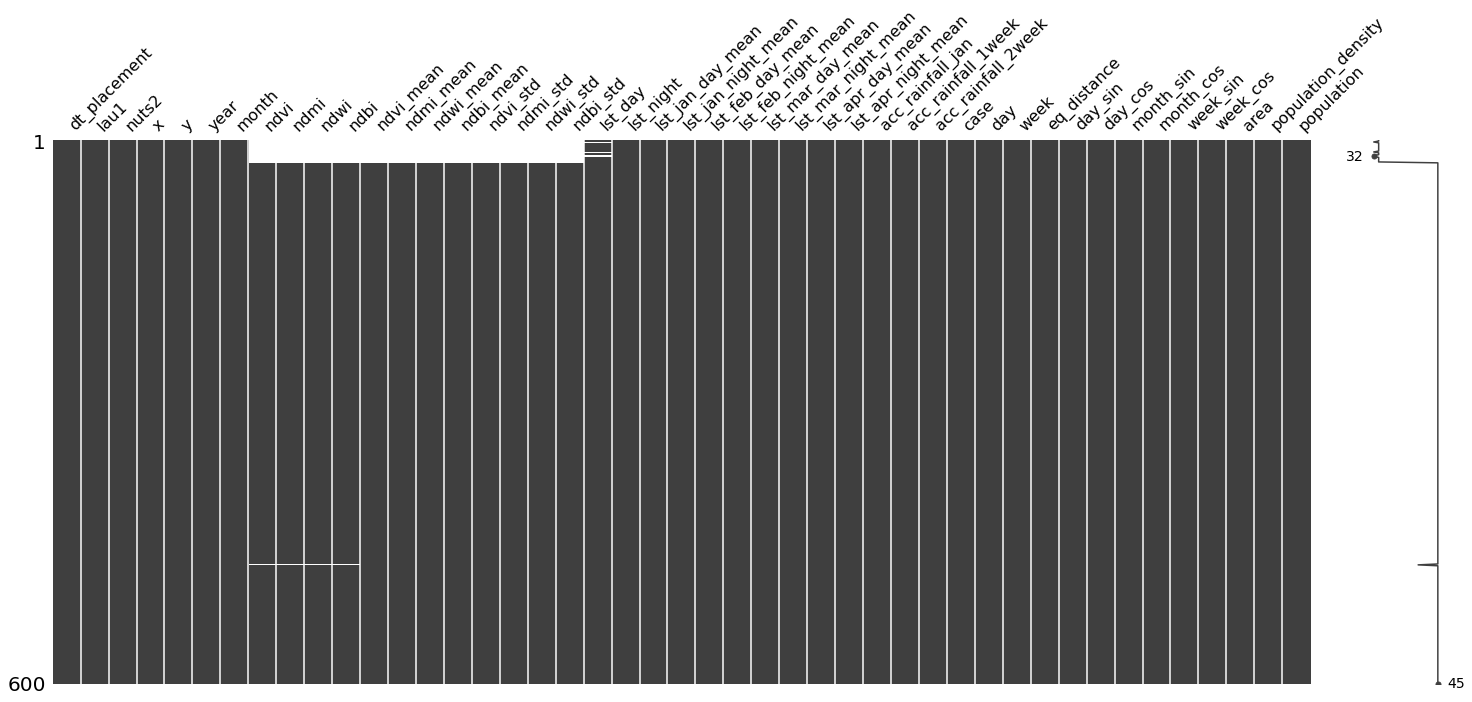

In [39]:
missingno.matrix(dataset)

In [40]:
missing = describe_dataframe(dataset)

In [41]:
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case,day,week,eq_distance,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population_density,population
0,2022-01-01,αγιας,θεσσαλιας,22.75027,39.71097,2022,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14281.000000,14035.142857,13946.530227,13768.484943,14128.912163,13770.359127,14179.946149,13771.168878,14711.620173,14042.292792,0.000000,0.000000,0.000000,0,1,52,45.76610,0.201299,0.979530,5.000000e-01,0.866025,-0.118273,0.992981,661.8,17.3,10705.00
1,2022-01-01,αλμυρου,θεσσαλιας,22.69237,39.13639,2022,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14276.375000,14013.555556,14088.341244,13747.596594,14238.749179,13798.552357,14311.203612,13789.415103,14789.425744,14140.293954,0.000138,0.000138,0.000138,0,1,52,45.23937,0.201299,0.979530,5.000000e-01,0.866025,-0.118273,0.992981,905.4,20.6,16004.00
2,2022-01-01,αλοννησου,θεσσαλιας,24.07379,39.32896,2022,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14198.000000,14205.400000,14069.857143,14291.307692,14036.666667,14283.900000,14011.818182,14607.631579,14277.666667,0.453699,0.453699,0.453699,0,1,52,46.11198,0.201299,0.979530,5.000000e-01,0.866025,-0.118273,0.992981,129.6,21.2,3153.00
3,2022-01-01,αργιθεας,θεσσαλιας,21.43051,39.22138,2022,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14173.000000,13969.333333,13813.000000,13614.968219,13999.987179,13683.657576,13976.834832,13600.170655,14591.410256,13998.950794,0.455287,0.455287,0.455287,0,1,52,44.69433,0.201299,0.979530,5.000000e-01,0.866025,-0.118273,0.992981,372.9,9.3,3515.00
4,2022-01-01,βολου,θεσσαλιας,22.88380,39.35198,2022,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14046.333333,14105.000000,14171.453199,13762.569853,14326.441392,13838.500000,14388.153691,13777.372727,14890.170868,14143.785577,0.000000,0.000000,0.000000,0,1,52,45.52194,0.201299,0.979530,5.000000e-01,0.866025,-0.118273,0.992981,385.6,374.6,138865.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,2022-12-16,τεμπων,θεσσαλιας,22.55316,39.85211,2022,12,0.477759,0.152211,-0.389123,-0.152211,0.487939,0.144348,-0.411254,-0.144348,0.051411,0.071228,0.041737,0.071228,14257.000000,14170.400000,13888.346715,13683.892353,14095.155711,13737.560404,14115.457669,13679.157980,14702.253277,14067.814982,1017.411256,8.098654,9.122005,0,16,50,45.79122,-0.101168,-0.994869,-2.449294e-16,1.000000,-0.348202,0.937420,576.7,23.8,11.99
596,2022-12-16,τρικκαιων,θεσσαλιας,21.79756,39.63506,2022,12,0.285819,0.004022,-0.221454,-0.004022,0.294226,0.022743,-0.223941,-0.022743,0.044244,0.050393,0.042606,0.050393,14352.200000,14113.200000,14130.884762,13666.107353,14346.223310,13730.069697,14418.705195,13728.572121,14922.437182,14123.490245,1050.398275,29.966226,30.347858,0,16,50,45.23352,-0.101168,-0.994869,-2.449294e-16,1.000000,-0.348202,0.937420,607.6,133.9,78508.00
597,2022-12-16,τυρναβου,θεσσαλιας,22.34300,39.82847,2022,12,0.453907,0.075541,-0.392130,-0.075541,0.392833,0.053335,-0.334736,-0.053335,0.046209,0.063514,0.034367,0.063514,14344.750000,14051.500000,14077.990981,13625.109743,14283.670940,13724.536859,14387.072650,13681.028283,14882.338796,14095.495475,1029.457235,12.195694,12.909679,0,16,50,45.66746,-0.101168,-0.994869,-2.449294e-16,1.000000,-0.348202,0.937420,525.3,47.7,22252.00
598,2022-12-16,φαρκαδονας,θεσσαλιας,22.02056,39.60375,2022,12,0.212071,-0.081474,-0.177903,0.081474,0.255763,-0.015408,-0.202076,0.015408,0.060588,0.067927,0.053202,0.067927,14396.666667,14040.333333,14094.681579,13694.162037,14337.983516,13768.886364,14429.993651,13768.516162,14981.5

In [42]:
df_mosquitoes = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Predictions_2022.csv', encoding = enc)
df_mosquitoes

,x,y,dt_placement,mosq_pred
0,22.750267,39.710970,2022-01-01,6
1,22.692366,39.136391,2022-01-01,5
2,24.073790,39.328960,2022-01-01,2
3,21.430513,39.221380,2022-01-01,12
4,22.883800,39.351977,2022-01-01,4
...,...,...,...,...
595,22.553160,39.852112,2022-12-16,41
596,21.797560,39.635058,2022-12-16,56
597,22.343000,39.828472,2022-12-16,58
598,22.020557,39.603750,2022-12-16,59


In [43]:
df_mosquitoes['dt_placement'] = pd.to_datetime(dataset['dt_placement'])
df_mosquitoes['x'] = df_mosquitoes['x'].apply(lambda x : round(x,5))
df_mosquitoes['y'] = df_mosquitoes['y'].apply(lambda x : round(x,5))

In [44]:
distances, indicies = calculate_nearest_topological(dataset, df_mosquitoes)

In [45]:
print(f'Min distance: {min(distances)}')
print(f'Max distance: {max(distances)}')

Min distance: 0.0
Max distance: 0.0008571819480130482


In [46]:
df_mosq = pd.DataFrame(columns=df_mosquitoes.columns)

In [47]:
for index in indicies:
    df_mosq = df_mosq.append(df_mosquitoes.iloc[[index]])

df_mosq.drop(columns=['x', 'y', 'dt_placement'], inplace = True)
df_mosq.reset_index(drop=True, inplace=True)

In [48]:
dataset = pd.concat([dataset, df_mosq], axis=1, join = 'outer')

In [49]:
dataset.head()

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case,day,week,eq_distance,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population_density,population,mosq_pred
0,2022-01-01,αγιας,θεσσαλιας,22.75027,39.71097,2022,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14281.000000,14035.142857,13946.530227,13768.484943,14128.912163,13770.359127,14179.946149,13771.168878,14711.620173,14042.292792,0.000000,0.000000,0.000000,0,1,52,45.76610,0.201299,0.97953,0.5,0.866025,-0.118273,0.992981,661.8,17.3,10705.0,6
1,2022-01-01,αλμυρου,θεσσαλιας,22.69237,39.13639,2022,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14276.375000,14013.555556,14088.341244,13747.596594,14238.749179,13798.552357,14311.203612,13789.415103,14789.425744,14140.293954,0.000138,0.000138,0.000138,0,1,52,45.23937,0.201299,0.97953,0.5,0.866025,-0.118273,0.992981,905.4,20.6,16004.0,5
2,2022-01-01,αλοννησου,θεσσαλιας,24.07379,39.32896,2022,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14198.000000,14205.400000,14069.857143,14291.307692,14036.666667,14283.900000,14011.818182,14607.631579,14277.666667,0.453699,0.453699,0.453699,0,1,52,46.11198,0.201299,0.97953,0.5,0.866025,-0.118273,0.992981,129.6,21.2,3153.0,1
3,2022-01-01,αργιθεας,θεσσαλιας,21.43051,39.22138,2022,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14173.000000,13969.333333,13813.000000,13614.968219,13999.987179,13683.657576,13976.834832,13600.170655,14591.410256,13998.950794,0.455287,0.455287,0.455287,0,1,52,44.69433,0.201299,0.97953,0.5,0.866025,-0.118273,0.992981,372.9,9.3,3515.0,12
4,2022-01-01,βολου,θεσσαλιας,22.88380,39.35198,2022,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14046.333333,14105.000000,14171.453199,13762.569853,14326.441392,13838.500000,14388.153691,13777.372727,14890.170868,14143.785577,0.000000,0.000000,0.000000,0,1,52,45.52194,0.201299,0.97953,0.5,0.866025,-0.118273,0.992981,385.6,374.6,138865.0,45


<AxesSubplot:>

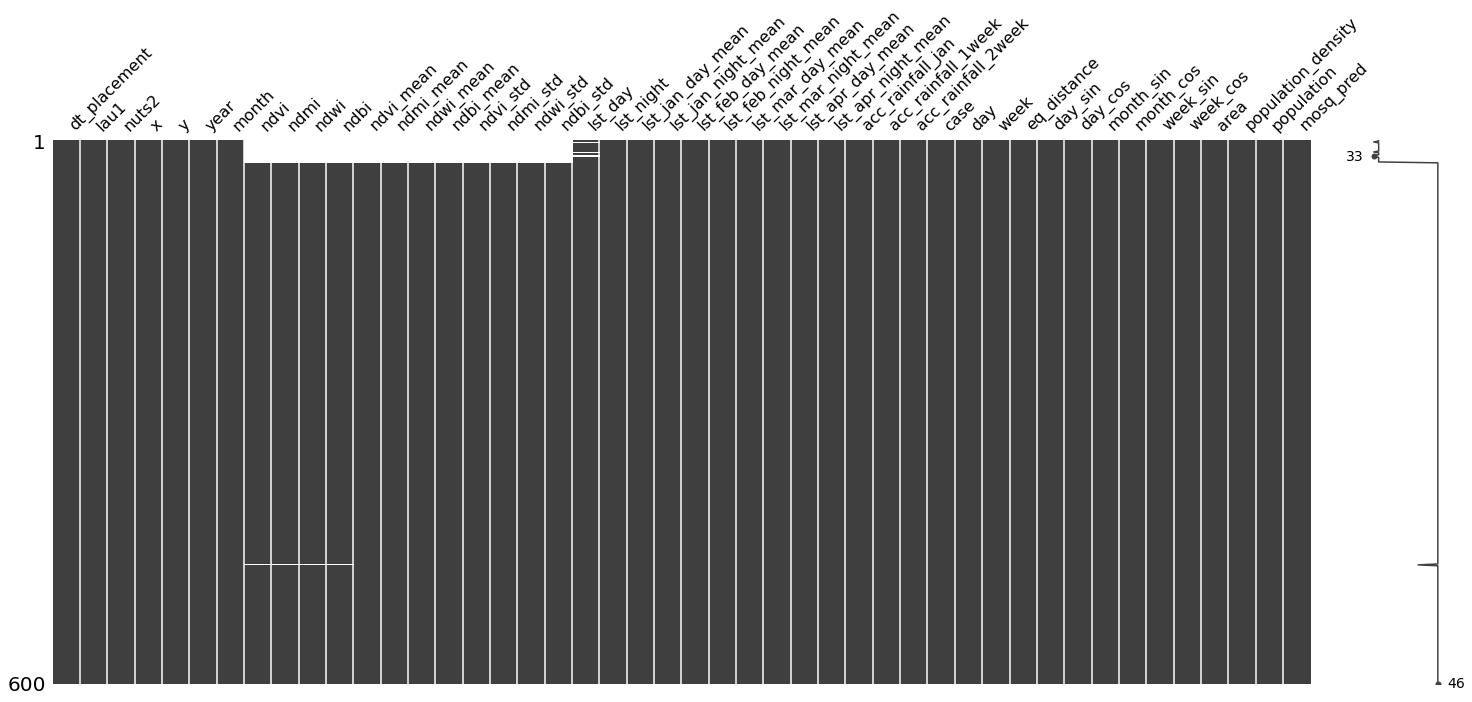

In [50]:
missingno.matrix(dataset)

In [51]:
dataset.reset_index(inplace=True, drop=True)

In [52]:
dataset = calculate_mosq_previous(dataset)

In [53]:
dataset = convert_temperature(dataset)

<AxesSubplot:>

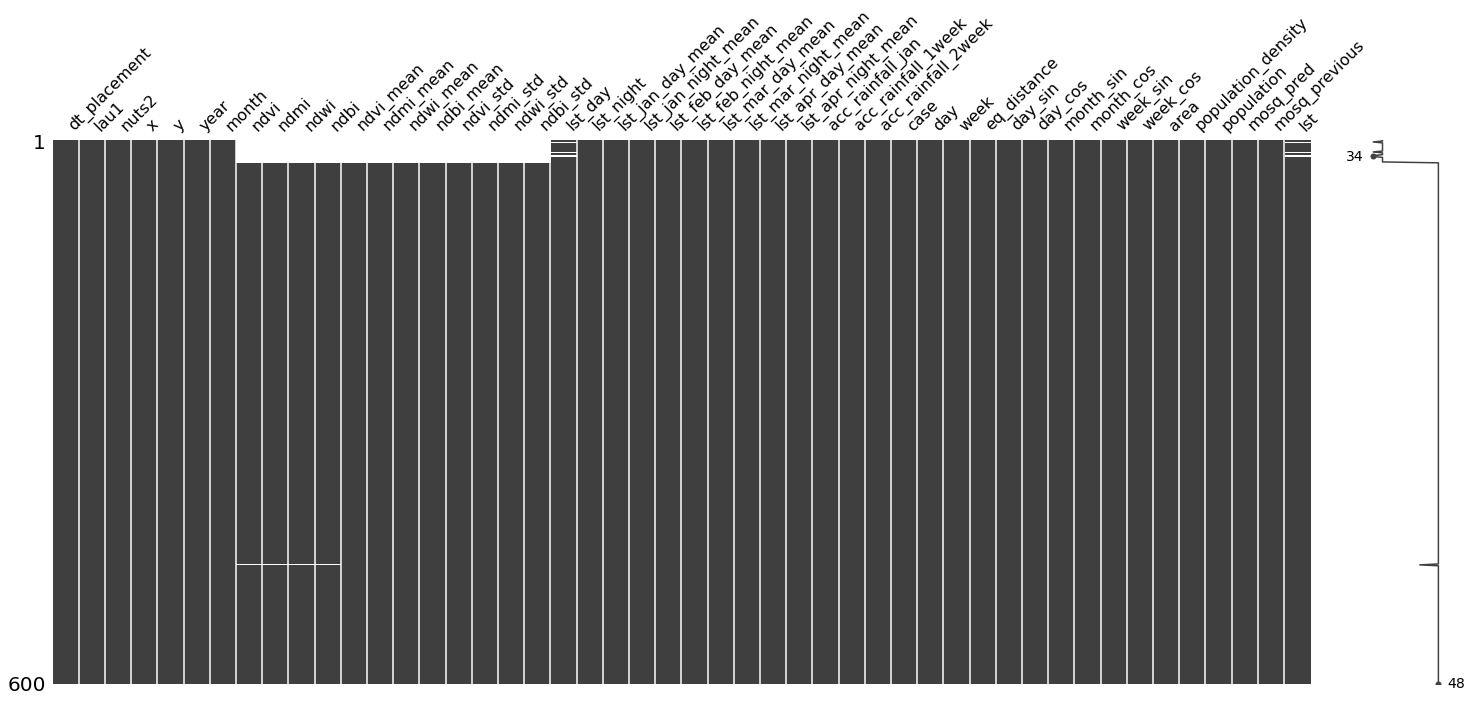

In [54]:
missingno.matrix(dataset)

In [55]:
dataset['case'].value_counts()

0    585
1      8
2      7
Name: case, dtype: int64

In [56]:
dataset = dataset.astype({'mosq_pred' : 'int', 'mosq_previous' : 'int'})

In [57]:
dataset = convert_multiple_cases(dataset)

In [58]:
dataset['case'].value_counts()

0    585
1     22
Name: case, dtype: int64

In [59]:
cols = dataset.columns

In [60]:
cols

Index(['dt_placement', 'lau1', 'nuts2', 'x', 'y', 'year', 'month', 'ndvi',
       'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean',
       'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_day_mean', 'lst_jan_night_mean',
       'lst_feb_day_mean', 'lst_feb_night_mean', 'lst_mar_day_mean',
       'lst_mar_night_mean', 'lst_apr_day_mean', 'lst_apr_night_mean',
       'acc_rainfall_jan', 'acc_rainfall_1week', 'acc_rainfall_2week', 'case',
       'day', 'week', 'eq_distance', 'day_sin', 'day_cos', 'month_sin',
       'month_cos', 'week_sin', 'week_cos', 'area', 'population_density',
       'population', 'mosq_pred', 'mosq_previous', 'lst'],
      dtype='object')

In [61]:
len(cols)

48

In [62]:
# check columns

In [63]:
final_columns = ['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'day', 
                 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 
                 'month_cos', 'week_sin', 'week_cos', 'area', 'population',
                 'population_density', 'eq_distance', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 
                 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 
                 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst',
                 'lst_day', 'lst_night','lst_jan_day_mean', 'lst_jan_night_mean', 
                 'lst_feb_day_mean','lst_feb_night_mean', 'lst_mar_day_mean', 
                 'lst_mar_night_mean', 'lst_apr_day_mean', 'lst_apr_night_mean',
                 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan',
                 'mosq_pred', 'mosq_previous', 'case']

In [64]:
len(final_columns)

48

In [65]:
dataset_final = dataset[final_columns].copy()

In [66]:
dataset_final

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,mosq_previous,case
0,22.75027,39.71097,2022-01-01,θεσσαλιας,αγιας,1,1,52,2022,0.201299,0.979530,0.500000,8.660254e-01,-0.118273,0.992981,661.8,10705.00,17.3,45.76610,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.011429,12.470000,7.552857,5.780605,2.219699,9.428243,2.257183,10.448923,2.273378,21.082403,7.695856,0.000000,0.000000,0.000000,6,0,0
1,22.69237,39.13639,2022-01-01,θεσσαλιας,αλμυρου,1,1,52,2022,0.201299,0.979530,0.500000,8.660254e-01,-0.118273,0.992981,905.4,16004.00,20.6,45.23937,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.749306,12.377500,7.121111,8.616825,1.801932,11.624984,2.821047,13.074072,2.638302,22.638515,9.655879,0.000138,0.000138,0.000138,5,0,0
2,24.07379,39.32896,2022-01-01,θεσσαλιας,αλοννησου,1,1,52,2022,0.201299,0.979530,0.500000,8.660254e-01,-0.118273,0.992981,129.6,3153.00,21.2,46.11198,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.810000,10.958000,8.247143,12.676154,7.583333,12.528000,7.086364,19.002632,12.403333,0.453699,0.453699,0.453699,1,0,0
3,21.43051,39.22138,2022-01-01,θεσσαλιας,αργιθεας,1,1,52,2022,0.201299,0.979530,0.500000,8.660254e-01,-0.118273,0.992981,372.9,3515.00,9.3,44.69433,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.273333,10.310000,6.236667,3.110000,-0.850636,6.849744,0.523152,6.386697,-1.146587,18.678205,6.829016,0.455287,0.455287,0.455287,12,0,0
4,22.88380,39.35198,2022-01-01,θεσσαλιας,βολου,1,1,52,2022,0.201299,0.979530,0.500000,8.660254e-01,-0.118273,0.992981,385.6,138865.00,374.6,45.52194,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.363333,7.776667,8.950000,10.279064,2.101397,13.378828,3.620000,14.613074,2.397455,24.653417,9.725712,0.000000,0.000000,0.000000,45,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
602,22.25731,39.56682,2022-09-01,θεσσαλιας,λαρισαιων,1,9,35,2022,0.201299,0.979530,-1.000000,-1.836970e-16,-0.845596,-0.533823,336.0,164381.00,483.9,45.39737,0.242602,-0.186117,-0.266601,0.186117,0.276567,-0.138791,-0.288544,0.138791,0.049921,0.061071,0.036903,0.061071,27.985000,35.770000,20.200000,10.551929,-1.222353,15.475000,0.971818,17.306667,0.820833,28.299333,9.236875,40.317953,178.762348,963.538026,98,196,1
603,22.55316,39.85211,2022-09-01,θεσσαλιας,τεμπων,1,9,35,2022,0.201299,0.979530,-1.000000,-1.836970e-16,-0.845596,-0.533823,576.7,11.99,23.8,45.79122,0.479267,0.122503,-0.414098,-0.122503,0.472816,0.110318,-0.411011,-0.110318,0.053853,0.068802,0.032873,0.068802,24.212000,30.174000,18.250000,4.616934,0.527847,8.753114,1.601208,9.159153,0.433160,20.895066,8.206300,17.438900,127.518770,863.056081,44,88,1
604,22.47968,39.49921,2022-09-16,θεσσαλιας,κιλελερ,16,9,37,2022,-0.101168,-0.994869,-1.000000,-1.836970e-16,-0.947326,-0.320270,976.3,18068.00,21.4,45.44803,0.262503,-0.107431,-0.291559,0.107431,0.238923,-0.123780,-0.276421,0.123780,0.062637,0.057462,0.046105,0.057462,28.587000,37.172000,20.002000,10.536281,-0.884103,14.919916,1.029070,17.326364,0.550680,26.305477,8.502701,0.000000,31.433345,1081.908031,5,10,1
605,22.25731,39.56682,2022-09-16,θεσσαλιας,λαρισαιων,16,9,37,2022,-0.101168,-0.994869,-1.000000,-1.836970e-16,-0.947326,-0.320270,336.0,164381.00,483.9,45.39737,0.341853,-0.096728,-0.341836,0.096728,0.328873,-0.097293,-0.335816,0.097293,0.033098,0.037200,0.023945,0.037200,26.390000,34.270000,18.510000,10.551929,-1.222353,15.475000,0.971818,17.306667,0.820833,28.299333,9.236875,0.000000,12.257309,992.252817,98,1

In [67]:
dataset_final.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_2022.csv", encoding = enc, index = False)